# 05 — Inference
### Diabetic Retinopathy Detection | APTOS 2019

**Goal:** Use the trained model to predict on any retinal image.  
We will:
1. Load the best saved model
2. Predict on a single image with confidence scores
3. Predict on a batch of custom images
4. Visualize prediction + GradCAM side by side
5. Export a clean `predict()` function you can reuse anywhere

---
## 0. Imports & Setup

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.config       import Config
from utils.dataset      import set_seed
from models.vgg16_model import VGG16Retinopathy

set_seed()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")

Device : cuda


---
## 1. Load Best Model

In [2]:
model = VGG16Retinopathy(
    num_classes=Config.NUM_CLASSES,
    dropout=Config.DROPOUT
).to(DEVICE)

model.load_state_dict(
    torch.load(Config.SAVE_PATH, map_location=DEVICE)
)
model.eval()
print(f"Loaded : {Config.SAVE_PATH}")
print(f"Model  : VGG16Retinopathy — {sum(p.numel() for p in model.parameters()):,} params")

Loaded : /teamspace/studios/this_studio/diabetic-retinopathy/outputs/best_model.pth
Model  : VGG16Retinopathy — 66,161,477 params


## 2. Inference Transforms & Helpers

In [3]:
infer_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(Config.MEAN, Config.STD),
])

inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(Config.MEAN, Config.STD)],
    std=[1/s for s in Config.STD]
)

def load_image(image_path):
    img  = Image.open(image_path).convert("RGB")
    tensor  = infer_tf(img)
    display = np.clip(
        inv_normalize(tensor).permute(1, 2, 0).numpy(), 0, 1
    )
    return tensor, display

print("Inference transform ready.")

Inference transform ready.


## 3. Core `predict()` Function

In [4]:
def predict(image_path, model, device, verbose=True):
    tensor, _ = load_image(image_path)
    inp       = tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(inp)
        probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred_grade = int(probs.argmax())
    confidence = float(probs[pred_grade])

    if verbose:
        print(f"Image      : {os.path.basename(image_path)}")
        print(f"Prediction : Grade {pred_grade} — {Config.CLASS_NAMES[pred_grade]}")
        print(f"Confidence : {confidence*100:.1f}%")
        print()
        print("Full probability breakdown:")
        for i, (name, p) in enumerate(zip(Config.CLASS_NAMES, probs)):
            bar    = "█" * int(p * 30)
            marker = " ◀" if i == pred_grade else ""
            print(f"  Grade {i} ({name:<15}): {p:.4f}  {bar}{marker}")

    return pred_grade, confidence, probs

print("predict() function defined.")

predict() function defined.


## 4. Single Image Prediction
Point `IMAGE_PATH` to any retinal fundus image on your machine.

In [6]:
import pandas as pd

# ── Pick a sample image from the val set ─────────────────────
# Replace this path with any retinal image you want to test
val_df     = pd.read_csv("outputs/val_split.csv")
sample_row = val_df.sample(1, random_state=7).iloc[0]
IMAGE_PATH = os.path.join(Config.TRAIN_IMGS, sample_row["id_code"] + ".png")
TRUE_GRADE = int(sample_row["diagnosis"])

print(f"Testing on : {sample_row['id_code']}.png")
print(f"True grade : {TRUE_GRADE} — {Config.CLASS_NAMES[TRUE_GRADE]}")
print()

pred_grade, confidence, probs = predict(IMAGE_PATH, model, DEVICE)

Testing on : b759cbef90c5.png
True grade : 0 — No DR

Image      : b759cbef90c5.png
Prediction : Grade 0 — No DR
Confidence : 99.2%

Full probability breakdown:
  Grade 0 (No DR          ): 0.9918  █████████████████████████████ ◀
  Grade 1 (Mild           ): 0.0045  
  Grade 2 (Moderate       ): 0.0029  
  Grade 3 (Severe         ): 0.0001  
  Grade 4 (Proliferative  ): 0.0008  


---
## 5. Prediction Plot — Image + Probability Bar Chart

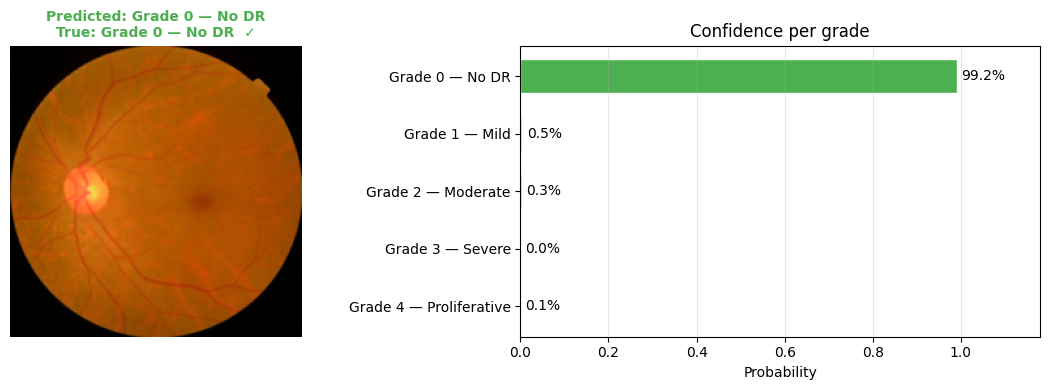

Saved: outputs/05_prediction.png


In [7]:
def plot_prediction(image_path, probs, true_grade=None):
    """Side-by-side: retinal image + horizontal probability bar chart."""
    _, img_display = load_image(image_path)
    pred_grade     = int(probs.argmax())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4),
                              gridspec_kw={"width_ratios": [1, 1.4]})

    # ── Left: retinal image ───────────────────────────────────
    axes[0].imshow(img_display)
    axes[0].axis("off")
    title = f"Predicted: Grade {pred_grade} — {Config.CLASS_NAMES[pred_grade]}"
    if true_grade is not None:
        correct = "✓" if pred_grade == true_grade else "✗"
        title  += f"\nTrue: Grade {true_grade} — {Config.CLASS_NAMES[true_grade]}  {correct}"
    axes[0].set_title(title, fontsize=10,
                      color=Config.CLASS_COLORS[pred_grade],
                      fontweight="bold")

    # ── Right: probability bar chart ──────────────────────────
    y_pos = np.arange(len(Config.CLASS_NAMES))
    colors = [
        Config.CLASS_COLORS[i] if i == pred_grade else "#cccccc"
        for i in range(len(Config.CLASS_NAMES))
    ]
    bars = axes[1].barh(y_pos, probs, color=colors,
                        edgecolor="white", height=0.6)
    for bar, p in zip(bars, probs):
        axes[1].text(
            bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{p*100:.1f}%", va="center", fontsize=10
        )
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(
        [f"Grade {i} — {n}" for i, n in enumerate(Config.CLASS_NAMES)]
    )
    axes[1].set_xlim(0, 1.18)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Confidence per grade")
    axes[1].grid(axis="x", alpha=0.3)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig("outputs/05_prediction.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_prediction(IMAGE_PATH, probs, true_grade=TRUE_GRADE)
print("Saved: outputs/05_prediction.png")

## 6. Prediction + GradCAM Overlay

In [9]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach())
        )
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach())
        )

    def generate(self, input_tensor, class_idx=None):
        for m in self.model.modules():
            if isinstance(m, nn.ReLU):
                m.inplace = False

        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Restore inplace
        for m in self.model.modules():
            if isinstance(m, nn.ReLU):
                m.inplace = True

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam).squeeze().cpu().numpy()
        cam    -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam, class_idx


gradcam = GradCAM(model, model.features[28])
print("GradCAM ready — hooked to model.features[28]")

GradCAM ready — hooked to model.features[28]


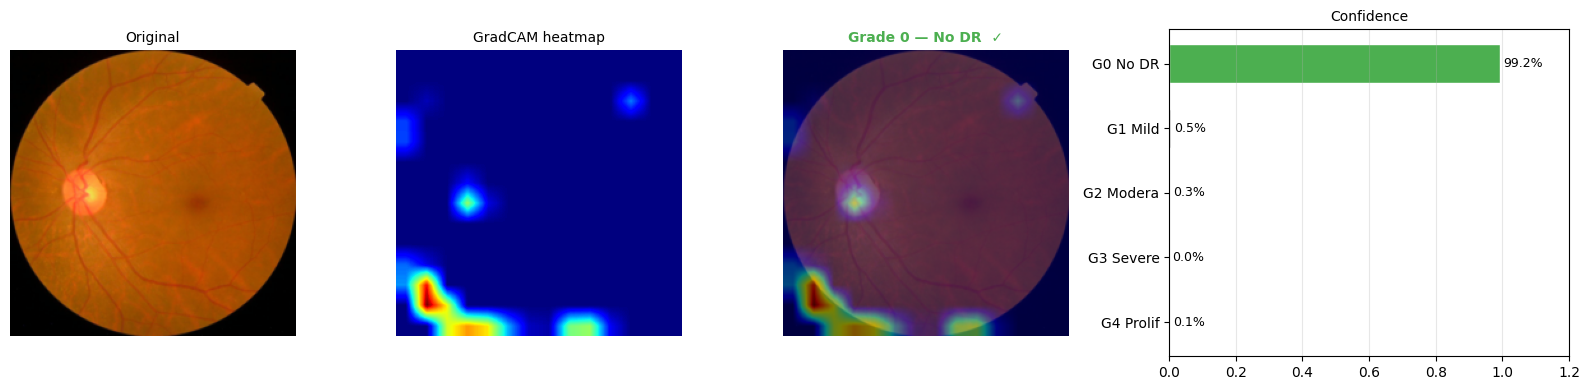

Saved: outputs/05_gradcam_inference.png


In [10]:
def plot_gradcam(image_path, model, gradcam, true_grade=None):
    """3-panel plot: original | heatmap | overlay + confidence bars."""
    tensor, img_display = load_image(image_path)
    inp = tensor.unsqueeze(0).to(DEVICE)

    cam, pred_grade = gradcam.generate(inp)

    with torch.no_grad():
        probs = torch.softmax(
            model(inp), dim=1
        )[0].cpu().numpy()

    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8))
             .resize((Config.IMG_SIZE, Config.IMG_SIZE), Image.BILINEAR)
    ) / 255.0

    heatmap = cm.jet(cam_resized)[:, :, :3]
    overlay = np.clip(0.5 * img_display + 0.5 * heatmap, 0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4),
                              gridspec_kw={"width_ratios": [1, 1, 1, 1.4]})

    label = f"Grade {pred_grade} — {Config.CLASS_NAMES[pred_grade]}"
    if true_grade is not None:
        correct = "✓" if pred_grade == true_grade else "✗"
        label  += f"  {correct}"

    axes[0].imshow(img_display)
    axes[0].set_title("Original", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(cam_resized, cmap="jet")
    axes[1].set_title("GradCAM heatmap", fontsize=10)
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(label, fontsize=10,
                      color=Config.CLASS_COLORS[pred_grade],
                      fontweight="bold")
    axes[2].axis("off")

    # Confidence bars
    y_pos  = np.arange(len(Config.CLASS_NAMES))
    colors = [
        Config.CLASS_COLORS[i] if i == pred_grade else "#cccccc"
        for i in range(len(Config.CLASS_NAMES))
    ]
    axes[3].barh(y_pos, probs, color=colors, edgecolor="white", height=0.6)
    for y, p in zip(y_pos, probs):
        axes[3].text(p + 0.01, y, f"{p*100:.1f}%", va="center", fontsize=9)
    axes[3].set_yticks(y_pos)
    axes[3].set_yticklabels(
        [f"G{i} {n[:6]}" for i, n in enumerate(Config.CLASS_NAMES)]
    )
    axes[3].set_xlim(0, 1.2)
    axes[3].set_title("Confidence", fontsize=10)
    axes[3].grid(axis="x", alpha=0.3)
    axes[3].invert_yaxis()

    plt.tight_layout()
    plt.savefig("outputs/05_gradcam_inference.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_gradcam(IMAGE_PATH, model, gradcam, true_grade=TRUE_GRADE)
print("Saved: outputs/05_gradcam_inference.png")

## 7. Batch Inference on Multiple Images

In [12]:
def predict_batch(image_paths, model, device):
    results = []
    model.eval()

    with torch.no_grad():
        for path in image_paths:
            tensor, _ = load_image(path)
            inp   = tensor.unsqueeze(0).to(device)
            probs = torch.softmax(model(inp), dim=1)[0].cpu().numpy()
            pred  = int(probs.argmax())
            results.append({
                "image":      os.path.basename(path),
                "pred_grade": pred,
                "grade_name": Config.CLASS_NAMES[pred],
                "confidence": round(float(probs[pred]), 4),
                **{f"prob_grade{i}": round(float(p), 4)
                   for i, p in enumerate(probs)}
            })

    return pd.DataFrame(results)


# ── Test on 10 random val images ──────────────────────────────
sample_10  = val_df.sample(10, random_state=42)
image_paths = [
    os.path.join(Config.TRAIN_IMGS, row["id_code"] + ".png")
    for _, row in sample_10.iterrows()
]
true_grades = sample_10["diagnosis"].tolist()

results_df = predict_batch(image_paths, model, DEVICE)
results_df["true_grade"] = true_grades
results_df["correct"]    = results_df["pred_grade"] == results_df["true_grade"]

print(results_df[["image", "true_grade", "pred_grade",
                  "grade_name", "confidence", "correct"]].to_string(index=False))
print()
acc = results_df["correct"].mean()
print(f"Accuracy on 10 samples : {acc*100:.0f}%")

           image  true_grade  pred_grade    grade_name  confidence  correct
eedae6b28f96.png           0           0         No DR      0.9994     True
c7e827fc7f41.png           2           4 Proliferative      0.4581    False
e39b627cf648.png           4           2      Moderate      0.5357    False
5a27b9b2a9c1.png           0           0         No DR      0.6446     True
bcc762618e7d.png           2           2      Moderate      0.6105     True
e1418d28d668.png           2           4 Proliferative      0.5702    False
6ccfdb031184.png           0           0         No DR      0.9878     True
ace287a5c991.png           0           1          Mild      0.5551    False
180afe1d5ef7.png           2           4 Proliferative      0.6237    False
5eb8fb1aad41.png           0           0         No DR      1.0000     True

Accuracy on 10 samples : 50%


## 8. Test on Your Own Image
Drop any retinal fundus image into the project folder and run this cell.

In [13]:
MY_IMAGE = "my_retinal_image.png"  

if os.path.exists(MY_IMAGE):
    pred_grade, confidence, probs = predict(MY_IMAGE, model, DEVICE)
    plot_gradcam(MY_IMAGE, model, gradcam)
else:
    print(f"File not found: {MY_IMAGE}")
    print("Place your retinal image in the project folder and update MY_IMAGE path.")
    print()
    print("Supported formats : .png, .jpg, .jpeg")
    print("Expected input    : colour fundus photograph, any resolution")

File not found: my_retinal_image.png
Place your retinal image in the project folder and update MY_IMAGE path.

Supported formats : .png, .jpg, .jpeg
Expected input    : colour fundus photograph, any resolution


## 9. Project Complete — Summary

In [15]:
print("=" * 58)
print("  PROJECT COMPLETE — Diabetic Retinopathy Detection")
print("=" * 58)
print()
print("  Notebooks:")
print("    01_eda.ipynb         Dataset exploration")
print("    02_preprocess.ipynb  Sampling, augmentation, DataLoaders")
print("    03_train.ipynb       VGG16 transfer learning + training")
print("    04_evaluate.ipynb    Metrics, confusion matrix, GradCAM")
print("    05_inference.ipynb   Single & batch prediction  ← you are here")
print()
print("  Shared modules:")
print("    utils/config.py      All hyperparameters")
print("    utils/dataset.py     Dataset class + DataLoaders")
print("    utils/metrics.py     Kappa, evaluate()")
print("    models/vgg16_model.py VGG16 with custom head")
print()
print("  Key outputs:")
print("    outputs/best_model.pth             Trained weights")
print("    outputs/train_split.csv            Reproducible split")
print("    outputs/03_training_history.csv    Epoch-by-epoch metrics")
print("    outputs/04_gradcam.png             Model attention maps")
print("    outputs/04_confusion_matrix.png    Error analysis")
print("=" * 58)

  PROJECT COMPLETE — Diabetic Retinopathy Detection

  Notebooks:
    01_eda.ipynb         Dataset exploration
    02_preprocess.ipynb  Sampling, augmentation, DataLoaders
    03_train.ipynb       VGG16 transfer learning + training
    04_evaluate.ipynb    Metrics, confusion matrix, GradCAM
    05_inference.ipynb   Single & batch prediction  ← you are here

  Shared modules:
    utils/config.py      All hyperparameters
    utils/dataset.py     Dataset class + DataLoaders
    utils/metrics.py     Kappa, evaluate()
    models/vgg16_model.py VGG16 with custom head

  Key outputs:
    outputs/best_model.pth             Trained weights
    outputs/train_split.csv            Reproducible split
    outputs/03_training_history.csv    Epoch-by-epoch metrics
    outputs/04_gradcam.png             Model attention maps
    outputs/04_confusion_matrix.png    Error analysis
